In [1]:
!pip install ucimlrepo


   ---------------------------------------- 2/2 [ucimlrepo]




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
mushroom = fetch_ucirepo(id=73)


In [ ]:
X = mushroom.data.features
y = mushroom.data.targets

# Combine into single DataFrame
df = pd.concat([X, y], axis=1)

# Display basic data
print(df.head())
print("Shape:", df.shape)

Shape: (8124, 23)


In [5]:
df.describe()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,...,9,9,1,4,3,5,9,6,7,2
top,x,y,n,f,n,f,c,b,b,t,...,w,w,p,w,o,p,w,v,d,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,...,4464,4384,8124,7924,7488,3968,2388,4040,3148,4208


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   cap-shape                 8124 non-null   str  
 1   cap-surface               8124 non-null   str  
 2   cap-color                 8124 non-null   str  
 3   bruises                   8124 non-null   str  
 4   odor                      8124 non-null   str  
 5   gill-attachment           8124 non-null   str  
 6   gill-spacing              8124 non-null   str  
 7   gill-size                 8124 non-null   str  
 8   gill-color                8124 non-null   str  
 9   stalk-shape               8124 non-null   str  
 10  stalk-root                5644 non-null   str  
 11  stalk-surface-above-ring  8124 non-null   str  
 12  stalk-surface-below-ring  8124 non-null   str  
 13  stalk-color-above-ring    8124 non-null   str  
 14  stalk-color-below-ring    8124 non-null   str  
 15

In [8]:
df.isnull().sum()

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
poisonous                      0
dtype: int64

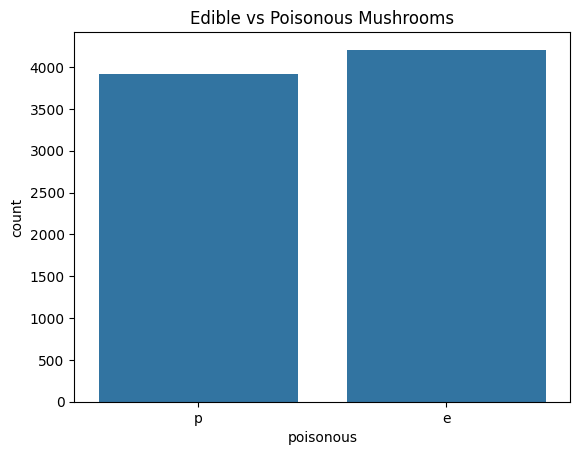

In [9]:
sns.countplot(x='poisonous', data=df)
plt.title("Edible vs Poisonous Mushrooms")
plt.show()

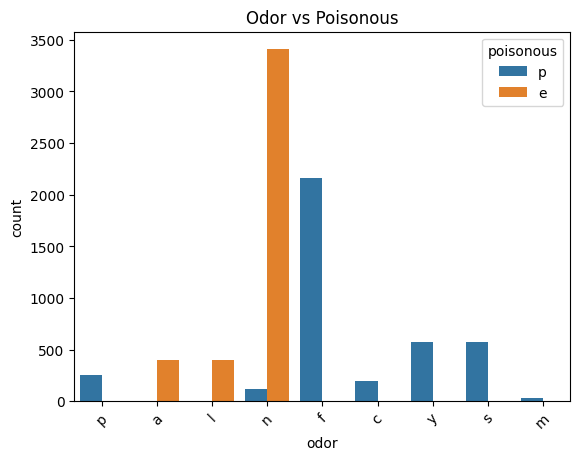

In [11]:
sns.countplot(x='odor', hue='poisonous', data=df)
plt.title("Odor vs Poisonous")
plt.xticks(rotation=45)
plt.show()

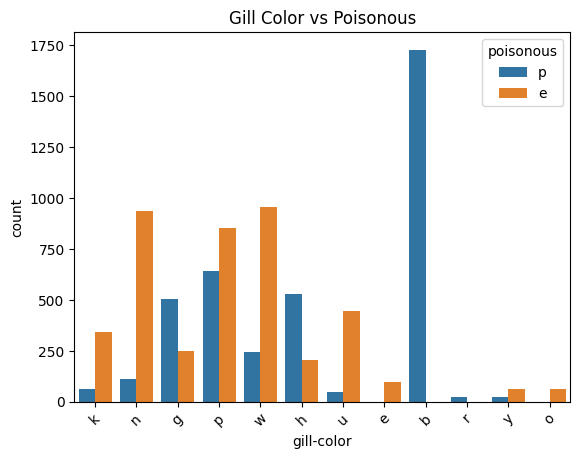

In [13]:
sns.countplot(x='gill-color', hue='poisonous', data=df)
plt.title("Gill Color vs Poisonous")
plt.xticks(rotation=45)
plt.show()

In [16]:
# Encode categorical data first
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# IQR Method
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

cap-shape: 0 outliers
cap-surface: 0 outliers
cap-color: 0 outliers
bruises: 0 outliers
odor: 0 outliers
gill-attachment: 210 outliers
gill-spacing: 1312 outliers
gill-size: 0 outliers
gill-color: 0 outliers
stalk-shape: 0 outliers
stalk-root: 0 outliers
stalk-surface-above-ring: 0 outliers
stalk-surface-below-ring: 0 outliers
stalk-color-above-ring: 1588 outliers
stalk-color-below-ring: 1652 outliers
veil-type: 0 outliers
veil-color: 200 outliers
ring-number: 636 outliers
ring-type: 0 outliers
spore-print-color: 0 outliers
population: 724 outliers
habitat: 192 outliers
poisonous: 0 outliers


In [18]:
df.replace('?', np.nan, inplace=True)

# Check missing values
print(df.isnull().sum())

# Remove missing values
df.dropna(inplace=True)

cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
poisonous                   0
dtype: int64


In [20]:
X = df.drop('poisonous', axis=1)
y = df['poisonous']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:

# Features and target
X = df.drop('poisonous', axis=1)
y = df['poisonous']

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (6499, 22)
Testing size: (1625, 22)


In [24]:
# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
# Predict
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [29]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[843   0]
 [  0 782]]


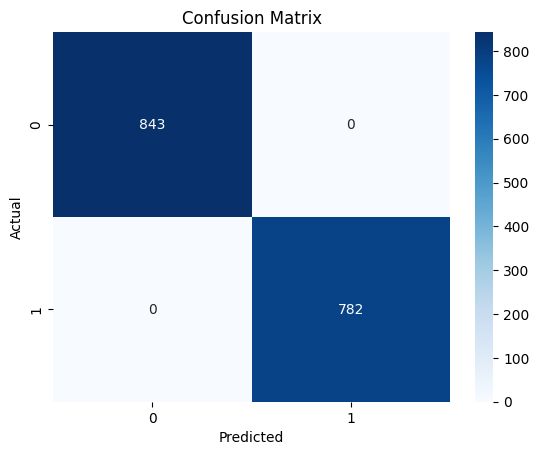

In [30]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

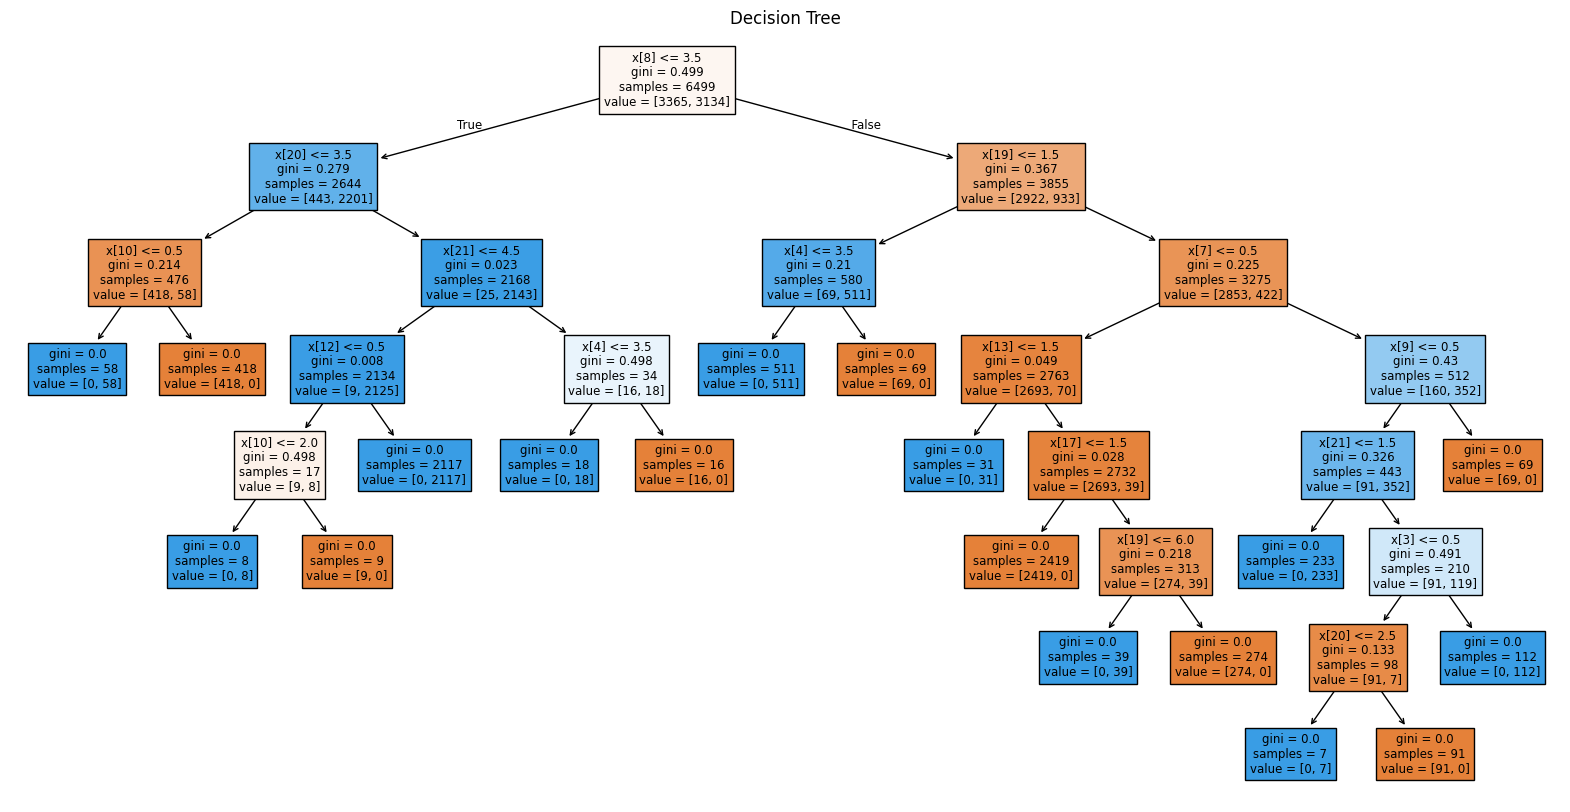

In [31]:
plt.figure(figsize=(20,10))
plot_tree(model, filled=True)
plt.title("Decision Tree")
plt.show()

In [32]:
results = []

for depth in [3, 5, 10]:
    for split in [2, 5, 10]:
        for leaf in [1, 2, 4]:

            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)

            results.append([depth, split, leaf, acc])

In [33]:
results_df = pd.DataFrame(results, columns=[
    "max_depth", "min_samples_split", "min_samples_leaf", "accuracy"
])

print(results_df.sort_values(by="accuracy", ascending=False))

    max_depth  min_samples_split  min_samples_leaf  accuracy
24         10                 10                 1  1.000000
25         10                 10                 2  1.000000
26         10                 10                 4  1.000000
19         10                  2                 2  1.000000
20         10                  2                 4  1.000000
21         10                  5                 1  1.000000
22         10                  5                 2  1.000000
23         10                  5                 4  1.000000
18         10                  2                 1  1.000000
10          5                  2                 2  0.976615
9           5                  2                 1  0.976615
12          5                  5                 1  0.976615
17          5                 10                 4  0.976615
15          5                 10                 1  0.976615
16          5                 10                 2  0.976615
11          5           

In [34]:
best_model = results_df.sort_values(by="accuracy", ascending=False).iloc[0]
print("Best Parameters:")
print(best_model)

Best Parameters:
max_depth            10.0
min_samples_split    10.0
min_samples_leaf      1.0
accuracy              1.0
Name: 24, dtype: float64
